In [1]:

import spatialdata as sd
import spatialdata_io
import spatialdata_plot
from napari_spatialdata import Interactive
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sdata = spatialdata_io.visium_hd('../data/Visium_HD_MouseBrain_FF/')

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.10/site-packages/spatialdata_io/readers/visium_hd.py:99: UserWarning: File ../data/Visium_HD_MouseBrain_FF/../data/Visium_HD_MouseBrain_FF/microscope_image/Visium_HD_Mouse_Brain_Fresh_Frozen_tissue_image.tif does not exis

In [4]:
sdata

SpatialData object
├── Images
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_hires_image': DataArray[cyx] (3, 4204, 6000)
│     └── 'Visium_HD_Mouse_Brain_Fresh_Frozen_lowres_image': DataArray[cyx] (3, 421, 600)
├── Shapes
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_002um': GeoDataFrame shape: (7238362, 1) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_008um': GeoDataFrame shape: (453820, 1) (2D shapes)
│     └── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_016um': GeoDataFrame shape: (113885, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (7238362, 19059)
      ├── 'square_008um': AnnData (453820, 19059)
      └── 'square_016um': AnnData (113885, 19059)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        Visium_HD_Mouse_Brain_Fresh_Frozen_hires_image (Images), Visium_HD_Mouse_Brain_Fresh_Frozen_square_002um (Shapes), Visium_HD_Mouse_Brain_Fresh_Frozen_square_008um (Shapes), Visium_HD_Mouse_Brain_Fresh_Frozen_square_016um (Shap

In [3]:
bin_sizes = [2, 8, 16]

for bin_size in bin_sizes:
    bin_name = "square_{:03d}um".format(bin_size)
    # Get average counts per bin
    print("Average counts per {}um bin:".format(bin_size), end=" ")
    print(sdata.tables[bin_name].X.sum(axis=1).mean())

    # Get average number of genes per bin
    print("Average number of genes per {}um bin:".format(bin_size), end=" ")
    print(sdata.tables[bin_name].X.astype(bool).sum(axis=1).mean())

Average counts per 2um bin: 64.67615
Average number of genes per 2um bin: 61.75602698511072
Average counts per 8um bin: 1032.1487
Average number of genes per 8um bin: 781.2303005596933
Average counts per 16um bin: 4115.074
Average number of genes per 16um bin: 2261.5830179567106


INFO     Rasterizing image for faster rendering.                                                                   


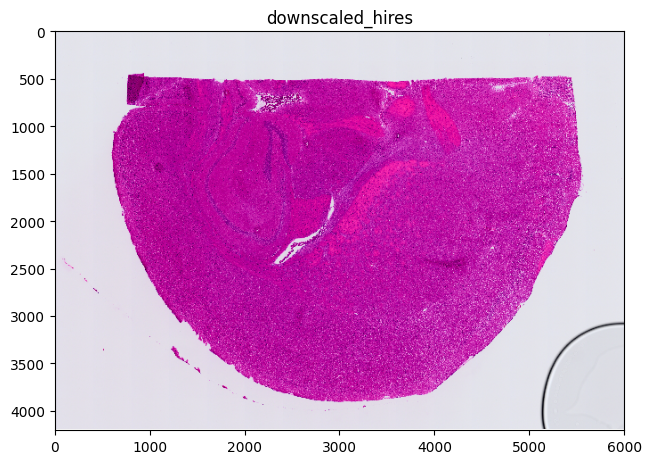

In [7]:
sdata.pl.render_images("Visium_HD_Mouse_Brain_Fresh_Frozen_hires_image").pl.show(coordinate_systems="downscaled_hires")

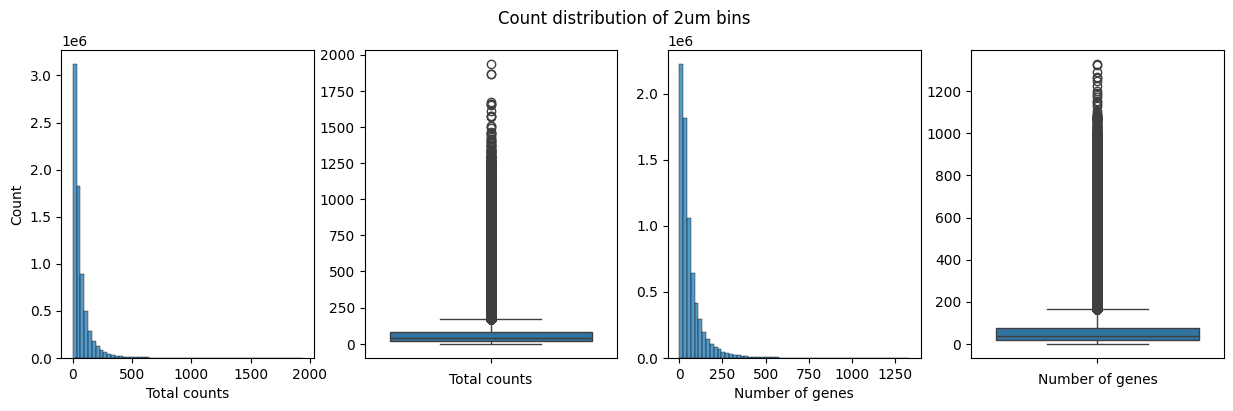

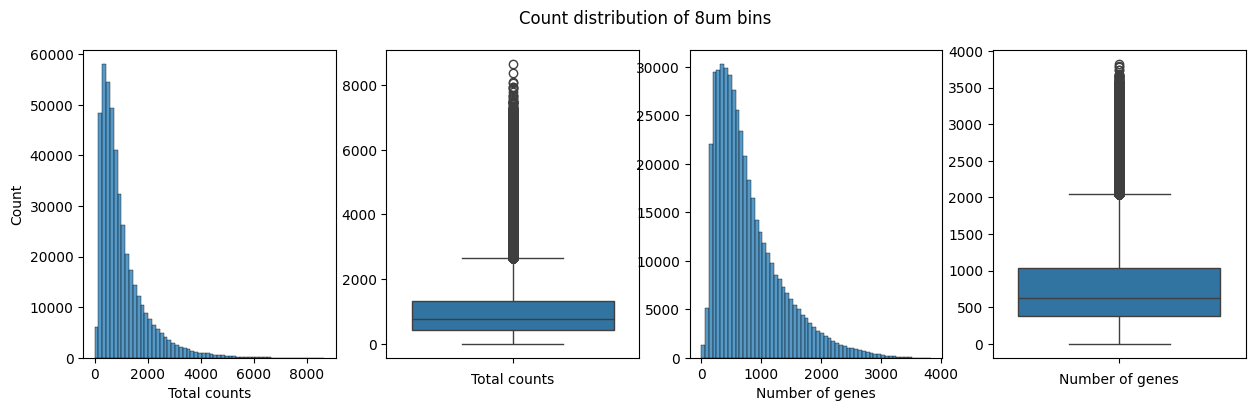

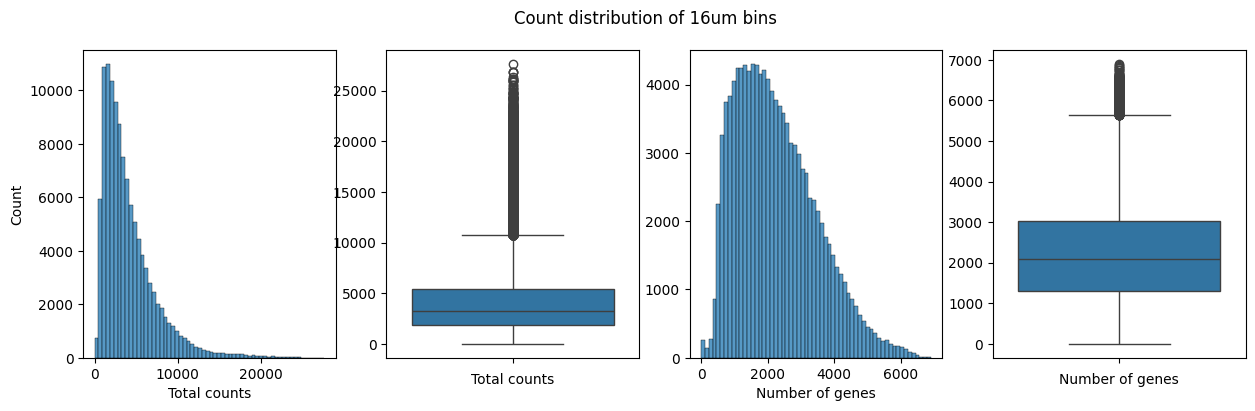

In [8]:
for bin_size in bin_sizes:
    bin_name = "square_{:03d}um".format(bin_size)
    
    # Count distribution per bin size
    adata = sdata.tables[bin_name]
    adata.obs["total_counts"] = adata.X.sum(axis=1)
    adata.obs["n_genes_by_counts"] = (adata.X > 0).sum(axis=1)

    fig, axs = plt.subplots(1, 4, figsize=(15, 4))
    sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
    sns.boxplot(adata.obs["total_counts"], ax=axs[1])

    sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
    sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])

    # Set overall title
    fig.suptitle("Count distribution of {}um bins".format(bin_size))

    # Set title and labels
    axs[0].set_xlabel("Total counts")
    axs[1].set_xlabel("Total counts")
    axs[2].set_xlabel("Number of genes")
    axs[3].set_xlabel("Number of genes")

    # Turn off y-axis title
    axs[1].set_ylabel("")
    axs[2].set_ylabel("")
    axs[3].set_ylabel("")
    
    # Save plot
    plt.savefig("plots/histogram_count_genes_{}um.png".format(bin_size), dpi=300)
